<a href="https://colab.research.google.com/github/Teomorales20/se-alesysistemas-/blob/main/00a2aFourierSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Complex exponential basis and orthogonality calculations
*Summary of Code Functionality*

- Defines complex exponential basis functions \( e^{j n \lambda t} \) with harmonics \( n \) and frequency parameter \( \lambda \).

- Calculates inner products using numerical integration methods:
  - Simpson's rule (preferred)
  - Trapezoidal rule (optional)

- Constructs the Gram matrix of inner products for all basis functions with harmonic indices ranging from \(-n_{max}\) to \(n_{max}\).

- Checks orthogonality of the basis functions by:
  - Verifying diagonal elements are close to the fundamental period \( T = \frac{2\pi}{\lambda} \).
  - Confirming off-diagonal elements are near zero.

- Includes plotting methods for visualizing:
  - Real and imaginary parts of basis functions.
  - Orthogonality demonstration between selected basis functions.
  - Heatmap of the Gram matrix (real and imaginary parts).

- Provides example usage demonstrating:
  - Orthogonality checks.
  - Inner product samples.
  - Effects of varying the frequency parameter \( \lambda \).
  - Generating plots for analysis.



Complex Exponential Basis Orthogonality Analysis
λ = 1.0
Fundamental period T = 2π/λ = 6.283185
Number of samples: 2048

1. Checking Orthogonality...
   Maximum off-diagonal error: 3.07e-03
   Is orthogonal? False
   Diagonal values accurate? True
   Theoretical norm: 6.283185

2. Sample Inner Products:
   ⟨φ_1, φ_1⟩ = 6.283185 + 0.000000j
   ⟨φ_1, φ_2⟩ = -0.003071 + -0.000005j
   ⟨φ_2, φ_1⟩ = -0.003071 + 0.000005j
   ⟨φ_2, φ_2⟩ = 6.283185 + 0.000000j

3. Effect of Different λ Values:
   λ = 0.5: T = 12.5664, Max off-diag error = 1.26e-02
   λ = 1.0: T = 6.2832, Max off-diag error = 6.30e-03
   λ = 2.0: T = 3.1416, Max off-diag error = 3.15e-03
   λ = 4.0: T = 1.5708, Max off-diag error = 1.57e-03

4. Convolution Example:

5. Generating Plots...


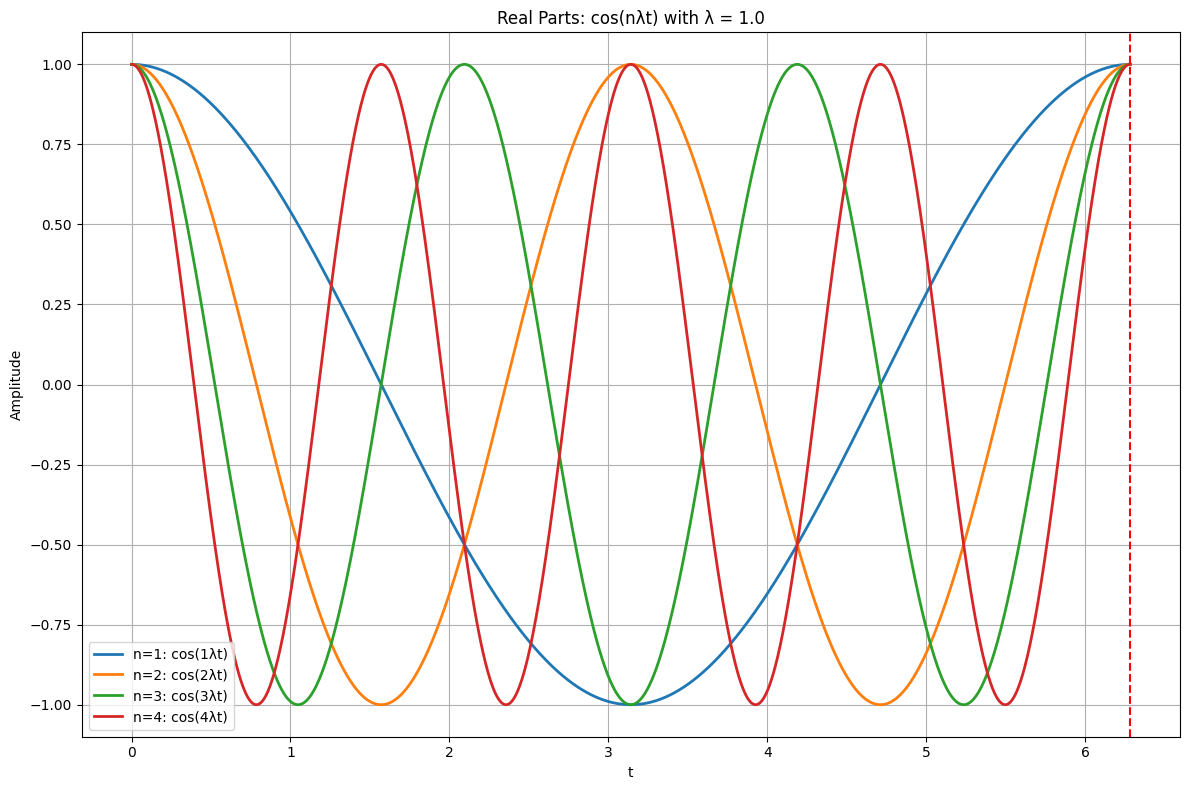

/tmp/ipython-input-3844085497.py:226: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(product, dx=dt)


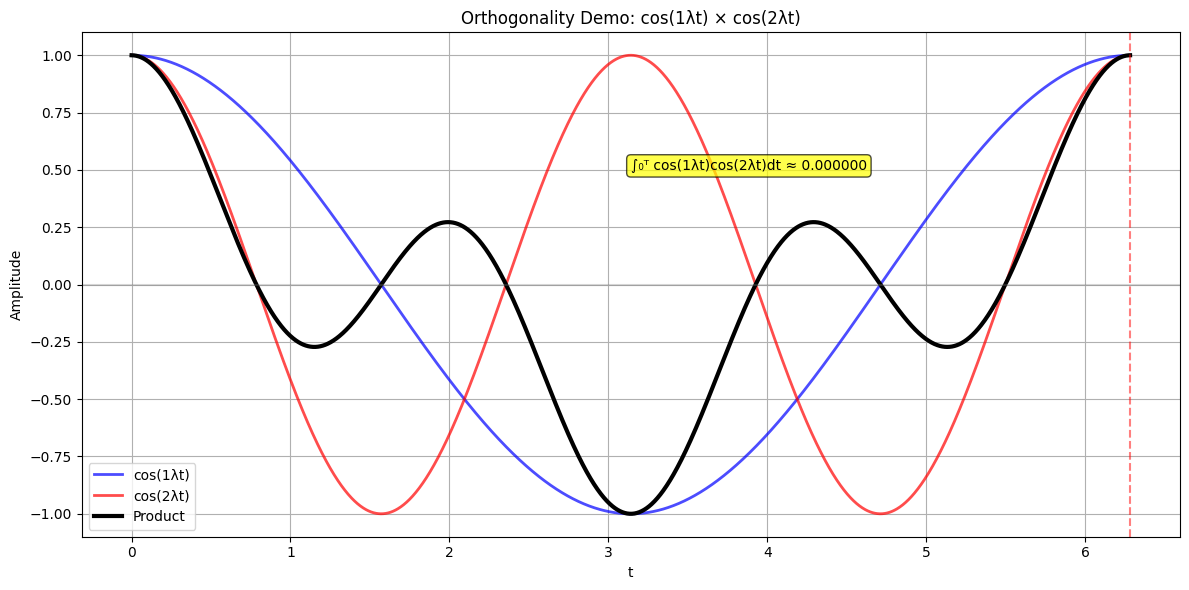

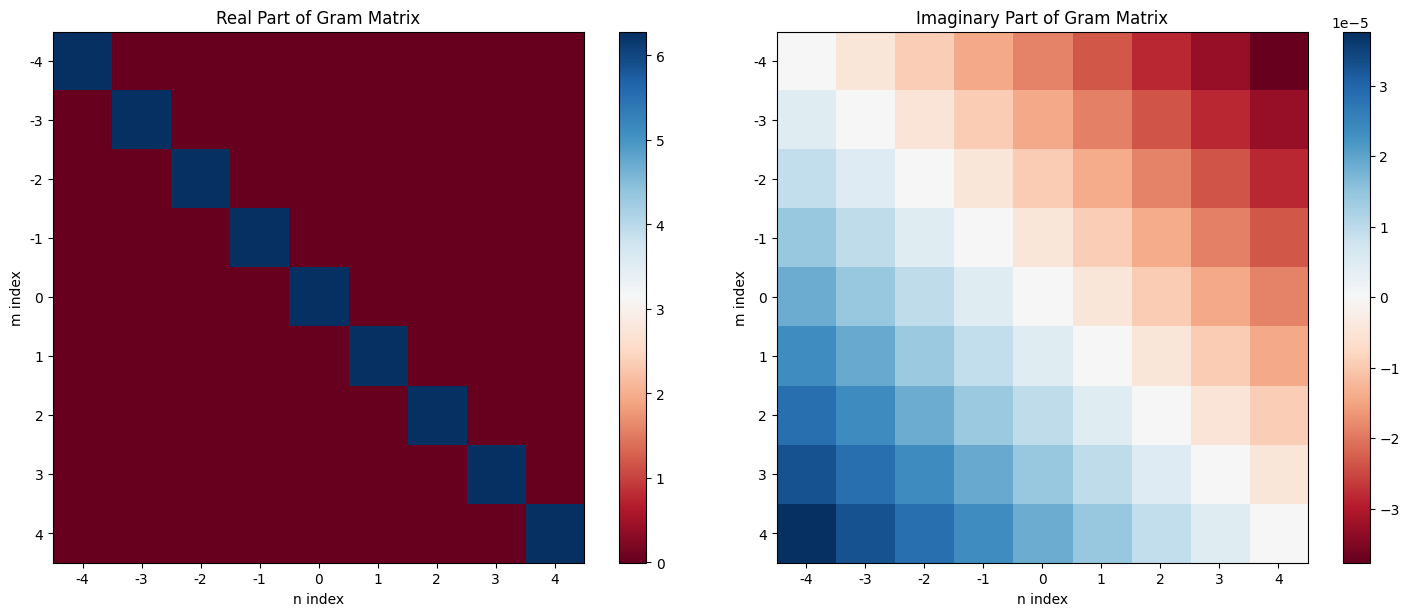


Analysis complete!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import pi, exp, cos, sin
import torch.nn.functional as F

class ComplexExponentialBasis:
    """
    PyTorch implementation for complex exponential basis functions
    and orthogonality calculations
    """

    def __init__(self, lambda_param=1.0, n_max=5, n_samples=1024, device='cpu'):
        """
        Initialize the complex exponential basis

        Args:
            lambda_param (float): The frequency parameter λ
            n_max (int): Maximum harmonic number to consider
            n_samples (int): Number of time samples
            device (str): PyTorch device ('cpu' or 'cuda')
        """
        self.lambda_param = lambda_param
        self.n_max = n_max
        self.n_samples = n_samples
        self.device = device

        # Fundamental period T = 2π/λ
        self.T = 2 * pi / lambda_param

        # Time vector from 0 to T
        self.t = torch.linspace(0, self.T, n_samples, device=device)

        # Harmonic indices (including negative frequencies)
        self.n_indices = torch.arange(-n_max, n_max + 1, device=device)

    def complex_exponential(self, n, t=None):
        """
        Compute complex exponential function e^(jnλt)

        Args:
            n (int or tensor): Harmonic number(s)
            t (tensor, optional): Time vector. If None, uses self.t

        Returns:
            torch.complex: Complex exponential values
        """
        if t is None:
            t = self.t

        # Convert to complex tensor
        if not torch.is_complex(t):
            t = t.to(torch.complex64)

        # Calculate jnλt
        exponent = 1j * n * self.lambda_param * t

        return torch.exp(exponent)

    def real_part(self, n, t=None):
        """Get real part: cos(nλt)"""
        return torch.real(self.complex_exponential(n, t))

    def imag_part(self, n, t=None):
        """Get imaginary part: sin(nλt)"""
        return torch.imag(self.complex_exponential(n, t))

    def inner_product(self, m, n, use_simpson=True):
        """
        Compute inner product ⟨φ_m, φ_n⟩ = ∫₀ᵀ e^(jmλt) * conj(e^(jnλt)) dt

        Args:
            m, n (int): Harmonic numbers
            use_simpson (bool): Use Simpson's rule for integration

        Returns:
            torch.complex: Inner product value
        """
        # Get the two functions
        phi_m = self.complex_exponential(m)
        phi_n = self.complex_exponential(n)

        # Compute integrand: φ_m * conj(φ_n)
        integrand = phi_m * torch.conj(phi_n)

        if use_simpson:
            # Simpson's rule integration
            result = self._simpson_integrate(integrand)
        else:
            # Simple trapezoidal integration
            dt = self.T / (self.n_samples - 1)
            result = torch.trapz(integrand, dx=dt)

        return result

    def _simpson_integrate(self, y):
        """Simpson's rule integration"""
        n = len(y)
        if n % 2 == 0:  # Make sure we have odd number of points
            y = y[:-1]
            n = len(y)

        h = self.T / (n - 1)

        # Simpson's rule: h/3 * [y0 + 4*y1 + 2*y2 + 4*y3 + ... + 4*y_{n-2} + yn]
        result = y[0] + y[-1]
        result += 4 * torch.sum(y[1:-1:2])  # Odd indices
        result += 2 * torch.sum(y[2:-1:2])  # Even indices (except first and last)

        return result * h / 3

    def compute_gram_matrix(self):
        """
        Compute the Gram matrix of inner products for all basis functions

        Returns:
            torch.tensor: Gram matrix G[i,j] = ⟨φ_i, φ_j⟩
        """
        n_funcs = len(self.n_indices)
        gram_matrix = torch.zeros((n_funcs, n_funcs), dtype=torch.complex64, device=self.device)

        for i, m in enumerate(self.n_indices):
            for j, n in enumerate(self.n_indices):
                gram_matrix[i, j] = self.inner_product(m, n)

        return gram_matrix

    def check_orthogonality(self, tolerance=1e-6):
        """
        Check orthogonality of the basis functions

        Args:
            tolerance (float): Numerical tolerance for orthogonality

        Returns:
            dict: Results of orthogonality check
        """
        gram_matrix = self.compute_gram_matrix()

        # Check diagonal elements (should be T = 2π/λ)
        diagonal = torch.diag(gram_matrix)
        theoretical_norm = self.T

        # Check off-diagonal elements (should be 0)
        mask = torch.eye(len(self.n_indices), device=self.device).bool()
        off_diagonal = gram_matrix[~mask]

        results = {
            'gram_matrix': gram_matrix,
            'diagonal_values': diagonal,
            'theoretical_norm': theoretical_norm,
            'diagonal_error': torch.abs(torch.real(diagonal) - theoretical_norm),
            'off_diagonal_values': off_diagonal,
            'max_off_diagonal': torch.max(torch.abs(off_diagonal)),
            'is_orthogonal': torch.max(torch.abs(off_diagonal)) < tolerance,
            'diagonal_accurate': torch.max(torch.abs(torch.real(diagonal) - theoretical_norm)) < tolerance
        }

        return results

    def plot_basis_functions(self, plot_type='real'):
        """
        Plot the basis functions

        Args:
            plot_type (str): 'real', 'imag', or 'both'
        """
        t_np = self.t.cpu().numpy()

        plt.figure(figsize=(12, 8))

        # Plot selected harmonics
        harmonics_to_plot = [1, 2, 3, 4] if self.n_max >= 4 else list(range(1, self.n_max + 1))

        if plot_type in ['real', 'both']:
            plt.subplot(2 if plot_type == 'both' else 1, 1, 1)
            for n in harmonics_to_plot:
                real_part = self.real_part(n).cpu().numpy()
                plt.plot(t_np, real_part, label=f'n={n}: cos({n}λt)', linewidth=2)

            plt.xlabel('t')
            plt.ylabel('Amplitude')
            plt.title(f'Real Parts: cos(nλt) with λ = {self.lambda_param}')
            plt.legend()
            plt.grid(True)
            plt.axvline(x=self.T, color='red', linestyle='--',
                         label=f'T = 2π/λ = {self.T:.3f}')

        if plot_type in ['imag', 'both']:
            plt.subplot(2 if plot_type == 'both' else 1, 1, 2 if plot_type == 'both' else 1)
            for n in harmonics_to_plot:
                imag_part = self.imag_part(n).cpu().numpy()
                plt.plot(t_np, imag_part, label=f'n={n}: sin({n}λt)', linewidth=2)

            plt.xlabel('t')
            plt.ylabel('Amplitude')
            plt.title(f'Imaginary Parts: sin(nλt) with λ = {self.lambda_param}')
            plt.legend()
            plt.grid(True)
            plt.axvline(x=self.T, color='red', linestyle='--',
                         label=f'T = 2π/λ = {self.T:.3f}')

        plt.tight_layout()
        plt.show()

    def plot_orthogonality_demo(self, m=1, n=2):
        """
        Demonstrate orthogonality by plotting two functions and their product
        """
        t_np = self.t.cpu().numpy()

        # Get the functions
        func_m = self.real_part(m).cpu().numpy()
        func_n = self.real_part(n).cpu().numpy()
        product = func_m * func_n

        plt.figure(figsize=(12, 6))

        plt.plot(t_np, func_m, 'b-', label=f'cos({m}λt)', alpha=0.7, linewidth=2)
        plt.plot(t_np, func_n, 'r-', label=f'cos({n}λt)', alpha=0.7, linewidth=2)
        plt.plot(t_np, product, 'k-', label=f'Product', linewidth=3)
        plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

        # Calculate integral
        dt = self.T / (self.n_samples - 1)
        integral = np.trapz(product, dx=dt)

        plt.xlabel('t')
        plt.ylabel('Amplitude')
        plt.title(f'Orthogonality Demo: cos({m}λt) × cos({n}λt)')
        plt.legend()
        plt.grid(True)
        plt.axvline(x=self.T, color='red', linestyle='--', alpha=0.5)

        # Add text annotation
        plt.text(0.5 * self.T, 0.5,
                 f'∫₀ᵀ cos({m}λt)cos({n}λt)dt ≈ {integral:.6f}',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

        plt.tight_layout()
        plt.show()

    def plot_gram_matrix(self):
        """Plot the Gram matrix as a heatmap"""
        gram_matrix = self.compute_gram_matrix()

        # Plot real and imaginary parts
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Real part
        real_part = torch.real(gram_matrix).cpu().numpy()
        im1 = ax1.imshow(real_part, cmap='RdBu', aspect='equal')
        ax1.set_title('Real Part of Gram Matrix')
        ax1.set_xlabel('n index')
        ax1.set_ylabel('m index')
        plt.colorbar(im1, ax=ax1)

        # Imaginary part
        imag_part = torch.imag(gram_matrix).cpu().numpy()
        im2 = ax2.imshow(imag_part, cmap='RdBu', aspect='equal')
        ax2.set_title('Imaginary Part of Gram Matrix')
        ax2.set_xlabel('n index')
        ax2.set_ylabel('m index')
        plt.colorbar(im2, ax=ax2)

        # Add grid and labels
        n_indices_np = self.n_indices.cpu().numpy()
        for ax in [ax1, ax2]:
            ax.set_xticks(range(len(n_indices_np)))
            ax.set_yticks(range(len(n_indices_np)))
            ax.set_xticklabels(n_indices_np)
            ax.set_yticklabels(n_indices_np)

        plt.tight_layout()
        plt.show()


# Example usage and calculations
if __name__ == "__main__":
    # Initialize the basis with λ = 1
    basis = ComplexExponentialBasis(lambda_param=1.0, n_max=4, n_samples=2048)

    print("Complex Exponential Basis Orthogonality Analysis")
    print("=" * 50)
    print(f"λ = {basis.lambda_param}")
    print(f"Fundamental period T = 2π/λ = {float(basis.T):.6f}")
    print(f"Number of samples: {basis.n_samples}")

    # Check orthogonality
    print("\n1. Checking Orthogonality...")
    results = basis.check_orthogonality()

    print(f"   Maximum off-diagonal error: {float(results['max_off_diagonal']):.2e}")
    print(f"   Is orthogonal? {results['is_orthogonal']}")
    print(f"   Diagonal values accurate? {results['diagonal_accurate']}")
    print(f"   Theoretical norm: {float(results['theoretical_norm']):.6f}")

    # Print some specific inner products
    print("\n2. Sample Inner Products:")
    for m in [1, 2]:
        for n in [1, 2]:
            inner_prod = basis.inner_product(m, n)
            print(f"   ⟨φ_{m}, φ_{n}⟩ = {float(torch.real(inner_prod)):.6f} + {float(torch.imag(inner_prod)):.6f}j")

    # Calculate with different λ values
    print("\n3. Effect of Different λ Values:")
    lambda_values = [0.5, 1.0, 2.0, 4.0]

    for lam in lambda_values:
        basis_temp = ComplexExponentialBasis(lambda_param=lam, n_max=3, n_samples=1000)
        results_temp = basis_temp.check_orthogonality()
        print(f"   λ = {lam}: T = {float(basis_temp.T):.4f}, Max off-diag error = {float(results_temp['max_off_diagonal']):.2e}")

    # Demonstrate convolution relationship
    print("\n4. Convolution Example:")
    # This would require additional implementation for convolution
    # but the inner product calculation is the key component

    # Plot results
    print("\n5. Generating Plots...")
    basis.plot_basis_functions('real')
    basis.plot_orthogonality_demo(1, 2)
    basis.plot_gram_matrix()

    print("\nAnalysis complete!")

Defining signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
w0 = 1.0

Theoretical analysis:
x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
     = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)
Expected coefficients:
X_3 = 0.05*(1-j) = 0.05 - 0.05j
X_{-3} = 0.05*(1+j) = 0.05 + 0.05j
All other X_n = 0
X_3 magnitude: 0.0707, phase: -0.7854 rad
X_{-3} magnitude: 0.0707, phase: 0.7854 rad

Calculating spectral coefficients...

Calculated spectral coefficients:
X_-6 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.0428 rad)
X_-5 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.1523 rad)
X_-4 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.1582 rad)
X_-3 = 0.050000 + -0.050000j (mag: 0.070711, phase: -0.7854 rad)
X_-2 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.0426 rad)
X_-1 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.1143 rad)
X_ 0 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.0000 rad)
X_ 1 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.1143 rad)
X_ 2 = 0.000000 + 0.000000j (mag

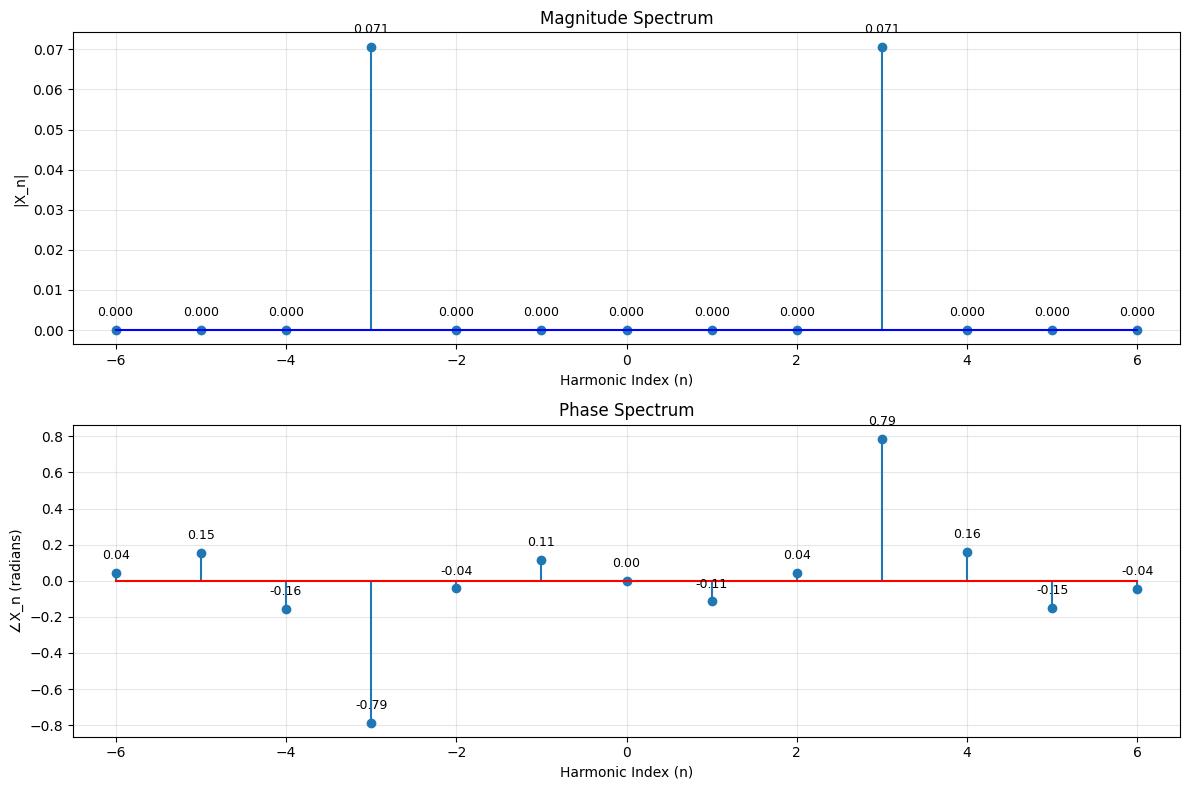

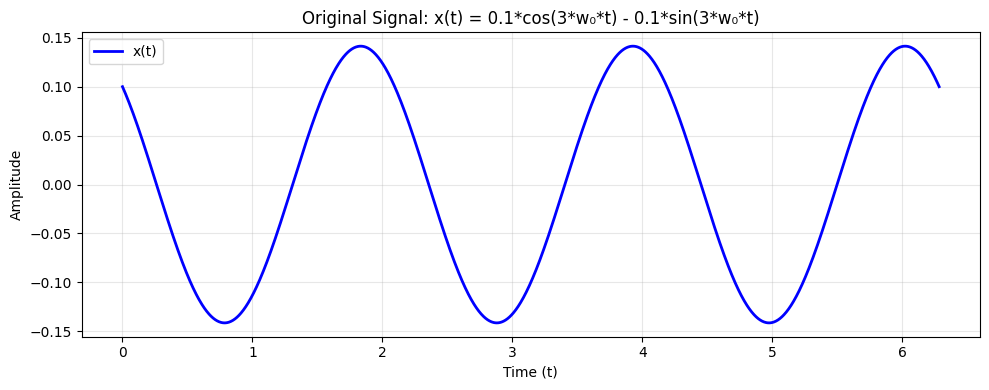

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

class ComplexExponentialBasis:
    def __init__(self, lambda_param=1.0, n_max=6, n_samples=2048):
        """
        Initialize complex exponential basis

        Args:
            lambda_param: fundamental frequency parameter
            n_max: maximum harmonic index
            n_samples: number of time samples
        """
        self.lambda_param = lambda_param
        self.n_max = n_max
        self.n_samples = n_samples

        # Create time vector from 0 to 2π/lambda_param
        self.t = torch.linspace(0, 2*np.pi/lambda_param, n_samples)

        # Create basis functions: e^(j*n*lambda*t) for n = -n_max to n_max
        self.basis_functions = {}
        self.harmonic_indices = list(range(-n_max, n_max + 1))

        for n in self.harmonic_indices:
            # Complex exponential: e^(j*n*lambda*t)
            self.basis_functions[n] = torch.exp(1j * n * lambda_param * self.t)

    def spectral_coefficients(self, x_t):
        """
        Calculate spectral coefficients using inner product with basis functions

        Args:
            x_t: input signal (torch tensor)

        Returns:
            dict: spectral coefficients for each harmonic
        """
        coefficients = {}
        dt = self.t[1] - self.t[0]  # time step

        for n in self.harmonic_indices:
            # Calculate inner product: <x(t), φ_n(t)> = ∫ x(t) * φ_n*(t) dt
            # φ_n*(t) is complex conjugate of basis function
            integrand = x_t * torch.conj(self.basis_functions[n])

            # Numerical integration using trapezoidal rule
            coefficient = torch.trapz(integrand, self.t)

            # Normalize by period length
            period = 2*np.pi/self.lambda_param
            coefficient = coefficient / period

            coefficients[n] = coefficient

        return coefficients

    def plot_spectral_coefficients(self, coefficients):
        """
        Plot magnitude and phase of spectral coefficients

        Args:
            coefficients: dictionary of spectral coefficients
        """
        # Extract harmonic indices and coefficients
        harmonics = list(coefficients.keys())
        coeffs = list(coefficients.values())

        # Convert to numpy for plotting
        coeffs_np = [c.numpy() if torch.is_tensor(c) else c for c in coeffs]

        # Calculate magnitudes and phases
        magnitudes = [np.abs(c) for c in coeffs_np]
        phases = [np.angle(c) for c in coeffs_np]

        # Create subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

        # Plot magnitude spectrum
        ax1.stem(harmonics, magnitudes, basefmt='b-')
        ax1.set_xlabel('Harmonic Index (n)')
        ax1.set_ylabel('|X_n|')
        ax1.set_title('Magnitude Spectrum')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(-self.n_max-0.5, self.n_max+0.5)

        # Add value labels for non-zero coefficients
        for i, (h, m) in enumerate(zip(harmonics, magnitudes)):
            if m > 1e-10:  # Only label significant coefficients
                ax1.annotate(f'{m:.3f}', (h, m), textcoords="offset points",
                           xytext=(0,10), ha='center', fontsize=9)

        # Plot phase spectrum
        # Only plot phases for coefficients with significant magnitude
        significant_harmonics = [h for h, m in zip(harmonics, magnitudes) if m > 1e-10]
        significant_phases = [p for h, p, m in zip(harmonics, phases, magnitudes) if m > 1e-10]

        if significant_phases:
            ax2.stem(significant_harmonics, significant_phases, basefmt='r-')
            ax2.set_xlabel('Harmonic Index (n)')
            ax2.set_ylabel('∠X_n (radians)')
            ax2.set_title('Phase Spectrum')
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim(-self.n_max-0.5, self.n_max+0.5)

            # Add phase labels
            for h, p in zip(significant_harmonics, significant_phases):
                ax2.annotate(f'{p:.2f}', (h, p), textcoords="offset points",
                           xytext=(0,10), ha='center', fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'No significant phases to display',
                    transform=ax2.transAxes, ha='center', va='center')
            ax2.set_xlabel('Harmonic Index (n)')
            ax2.set_ylabel('∠X_n (radians)')
            ax2.set_title('Phase Spectrum')

        plt.tight_layout()
        plt.show()

        return fig

# Main execution
if __name__ == "__main__":
    # Initialize the complex exponential basis
    basis = ComplexExponentialBasis(lambda_param=1.0, n_max=6, n_samples=2048)
    w0 = basis.lambda_param

    # Define the signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
    print("Defining signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)")
    print(f"w0 = {w0}")

    x_t = 0.1 * torch.cos(3 * w0 * basis.t) - 0.1 * torch.sin(3 * w0 * basis.t)

    # Alternative representation using complex exponentials
    # cos(3w0*t) = (e^(j*3*w0*t) + e^(-j*3*w0*t))/2
    # sin(3w0*t) = (e^(j*3*w0*t) - e^(-j*3*w0*t))/(2j)
    # So: 0.1*cos(3w0*t) - 0.1*sin(3w0*t) = 0.1*(e^(j*3*w0*t) + e^(-j*3*w0*t))/2 - 0.1*(e^(j*3*w0*t) - e^(-j*3*w0*t))/(2j)
    #                                      = 0.05*e^(j*3*w0*t) + 0.05*e^(-j*3*w0*t) - 0.05j*e^(j*3*w0*t) + 0.05j*e^(-j*3*w0*t)
    #                                      = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)

    print("\nTheoretical analysis:")
    print("x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)")
    print("     = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)")
    print("Expected coefficients:")
    print("X_3 = 0.05*(1-j) = 0.05 - 0.05j")
    print("X_{-3} = 0.05*(1+j) = 0.05 + 0.05j")
    print("All other X_n = 0")

    expected_X3 = 0.05 * (1 - 1j)
    expected_X_neg3 = 0.05 * (1 + 1j)
    print(f"X_3 magnitude: {abs(expected_X3):.4f}, phase: {np.angle(expected_X3):.4f} rad")
    print(f"X_{{-3}} magnitude: {abs(expected_X_neg3):.4f}, phase: {np.angle(expected_X_neg3):.4f} rad")

    # Calculate spectral coefficients
    print("\nCalculating spectral coefficients...")
    coeffs = basis.spectral_coefficients(x_t)

    # Display the calculated coefficients
    print("\nCalculated spectral coefficients:")
    for n in sorted(coeffs.keys()):
        coeff = coeffs[n]
        magnitude = abs(coeff)
        phase = np.angle(coeff)
        if magnitude > 1e-10:  # Only display significant coefficients
            print(f"X_{n:2d} = {coeff.real:.6f} + {coeff.imag:.6f}j "
                  f"(mag: {magnitude:.6f}, phase: {phase:.4f} rad)")

    # Plot the spectral coefficients
    print("\nPlotting spectral coefficients...")
    basis.plot_spectral_coefficients(coeffs)

    # Also plot the original signal for reference
    plt.figure(figsize=(10, 4))
    plt.plot(basis.t.numpy(), x_t.real.numpy(), 'b-', linewidth=2, label='x(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Original Signal: x(t) = 0.1*cos(3*w₀*t) - 0.1*sin(3*w₀*t)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ef1064c8-5ffe-4039-a3f4-6f71bb3de118' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

Defining signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
w0 = 1.0

Theoretical analysis:
x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
     = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)
Expected coefficients:
X_3 = 0.05*(1-j) = 0.05 - 0.05j
X_{-3} = 0.05*(1+j) = 0.05 + 0.05j
All other X_n = 0
X_3 magnitude: 0.0707, phase: -0.7854 rad
X_{-3} magnitude: 0.0707, phase: 0.7854 rad

Calculating spectral coefficients...

Calculated spectral coefficients:
X_-6 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.0428 rad)
X_-5 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.1523 rad)
X_-4 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.1582 rad)
X_-3 = 0.050000 + -0.050000j (mag: 0.070711, phase: -0.7854 rad)
X_-2 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.0426 rad)
X_-1 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.1143 rad)
X_ 0 = 0.000000 + 0.000000j (mag: 0.000000, phase: 0.0000 rad)
X_ 1 = 0.000000 + -0.000000j (mag: 0.000000, phase: -0.1143 rad)
X_ 2 = 0.000000 + 0.000000j (mag

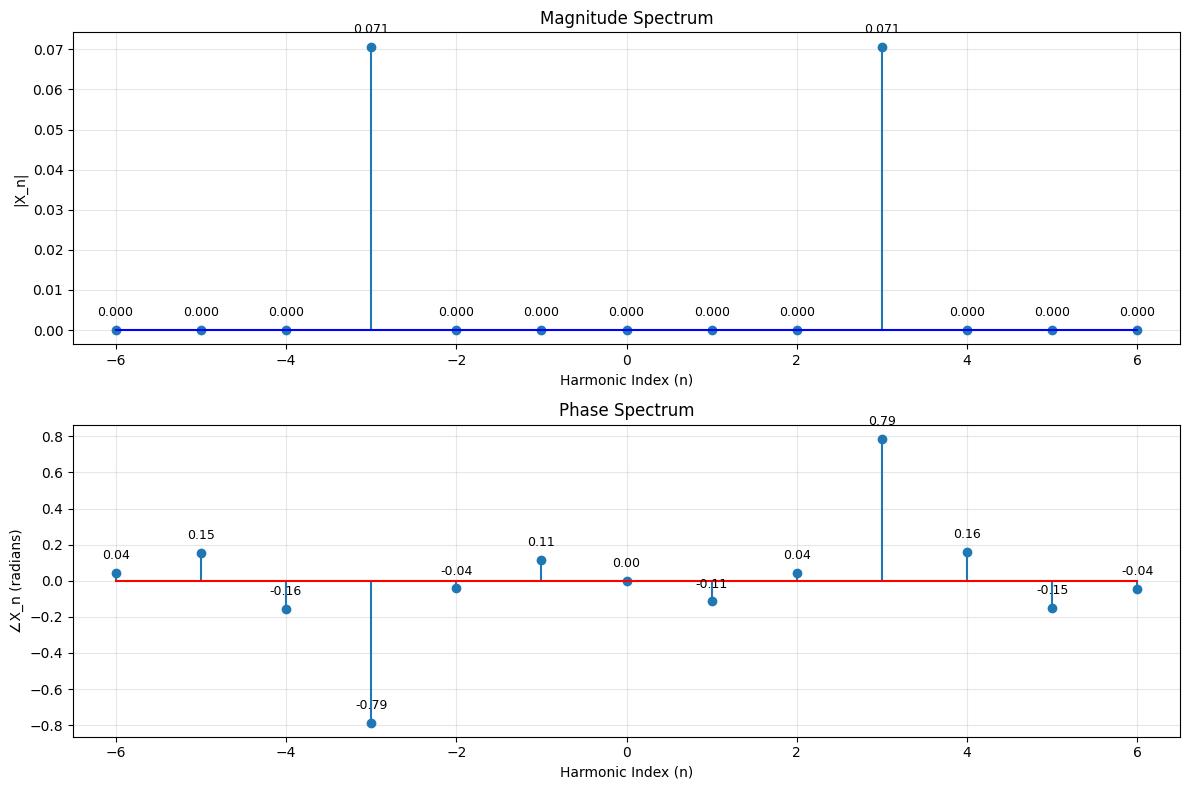

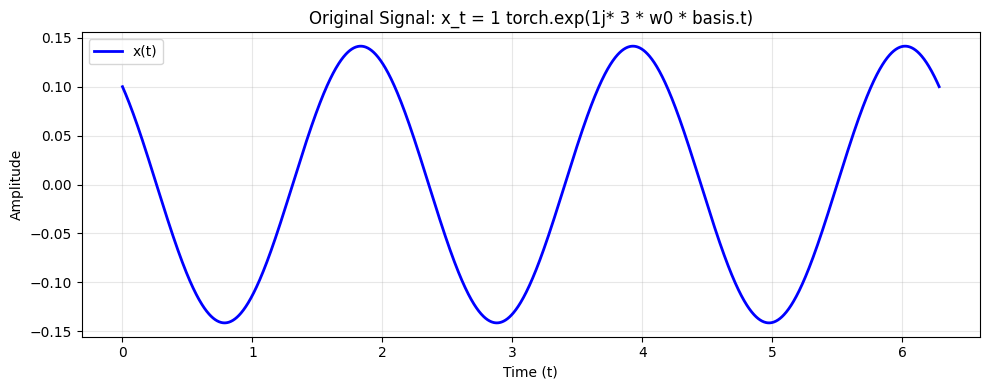

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

class ComplexExponentialBasis:
    def __init__(self, lambda_param=1.0, n_max=6, n_samples=2048):
        """
        Initialize complex exponential basis

        Args:
            lambda_param: fundamental frequency parameter
            n_max: maximum harmonic index
            n_samples: number of time samples
        """
        self.lambda_param = lambda_param
        self.n_max = n_max
        self.n_samples = n_samples

        # Create time vector from 0 to 2π/lambda_param
        self.t = torch.linspace(0, 2*np.pi/lambda_param, n_samples)

        # Create basis functions: e^(j*n*lambda*t) for n = -n_max to n_max
        self.basis_functions = {}
        self.harmonic_indices = list(range(-n_max, n_max + 1))

        for n in self.harmonic_indices:
            # Complex exponential: e^(j*n*lambda*t)
            self.basis_functions[n] = torch.exp(1j * n * lambda_param * self.t)

    def spectral_coefficients(self, x_t):
        """
        Calculate spectral coefficients using inner product with basis functions

        Args:
            x_t: input signal (torch tensor)

        Returns:
            dict: spectral coefficients for each harmonic
        """
        coefficients = {}
        dt = self.t[1] - self.t[0]  # time step

        for n in self.harmonic_indices:
            # Calculate inner product: <x(t), φ_n(t)> = ∫ x(t) * φ_n*(t) dt
            # φ_n*(t) is complex conjugate of basis function
            integrand = x_t * torch.conj(self.basis_functions[n])

            # Numerical integration using trapezoidal rule
            coefficient = torch.trapz(integrand, self.t)

            # Normalize by period length
            period = 2*np.pi/self.lambda_param
            coefficient = coefficient / period

            coefficients[n] = coefficient

        return coefficients

    def plot_spectral_coefficients(self, coefficients):
        """
        Plot magnitude and phase of spectral coefficients

        Args:
            coefficients: dictionary of spectral coefficients
        """
        # Extract harmonic indices and coefficients
        harmonics = list(coefficients.keys())
        coeffs = list(coefficients.values())

        # Convert to numpy for plotting
        coeffs_np = [c.numpy() if torch.is_tensor(c) else c for c in coeffs]

        # Calculate magnitudes and phases
        magnitudes = [np.abs(c) for c in coeffs_np]
        phases = [np.angle(c) for c in coeffs_np]

        # Create subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

        # Plot magnitude spectrum
        ax1.stem(harmonics, magnitudes, basefmt='b-')
        ax1.set_xlabel('Harmonic Index (n)')
        ax1.set_ylabel('|X_n|')
        ax1.set_title('Magnitude Spectrum')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(-self.n_max-0.5, self.n_max+0.5)

        # Add value labels for non-zero coefficients
        for i, (h, m) in enumerate(zip(harmonics, magnitudes)):
            if m > 1e-10:  # Only label significant coefficients
                ax1.annotate(f'{m:.3f}', (h, m), textcoords="offset points",
                           xytext=(0,10), ha='center', fontsize=9)

        # Plot phase spectrum
        # Only plot phases for coefficients with significant magnitude
        significant_harmonics = [h for h, m in zip(harmonics, magnitudes) if m > 1e-10]
        significant_phases = [p for h, p, m in zip(harmonics, phases, magnitudes) if m > 1e-10]

        if significant_phases:
            ax2.stem(significant_harmonics, significant_phases, basefmt='r-')
            ax2.set_xlabel('Harmonic Index (n)')
            ax2.set_ylabel('∠X_n (radians)')
            ax2.set_title('Phase Spectrum')
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim(-self.n_max-0.5, self.n_max+0.5)

            # Add phase labels
            for h, p in zip(significant_harmonics, significant_phases):
                ax2.annotate(f'{p:.2f}', (h, p), textcoords="offset points",
                           xytext=(0,10), ha='center', fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'No significant phases to display',
                    transform=ax2.transAxes, ha='center', va='center')
            ax2.set_xlabel('Harmonic Index (n)')
            ax2.set_ylabel('∠X_n (radians)')
            ax2.set_title('Phase Spectrum')

        plt.tight_layout()
        plt.show()

        return fig

# Main execution
if __name__ == "__main__":
    # Initialize the complex exponential basis
    basis = ComplexExponentialBasis(lambda_param=1.0, n_max=6, n_samples=2048)
    w0 = basis.lambda_param

    # Define the signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)
    print("Defining signal: x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)")
    print(f"w0 = {w0}")

    x_t = 0.1 * torch.cos(3 * w0 * basis.t) - 0.1 * torch.sin(3 * w0 * basis.t)

    # Alternative representation using complex exponentials
    # cos(3w0*t) = (e^(j*3*w0*t) + e^(-j*3*w0*t))/2
    # sin(3w0*t) = (e^(j*3*w0*t) - e^(-j*3*w0*t))/(2j)
    # So: 0.1*cos(3w0*t) - 0.1*sin(3w0*t) = 0.1*(e^(j*3*w0*t) + e^(-j*3*w0*t))/2 - 0.1*(e^(j*3*w0*t) - e^(-j*3*w0*t))/(2j)
    #                                      = 0.05*e^(j*3*w0*t) + 0.05*e^(-j*3*w0*t) - 0.05j*e^(j*3*w0*t) + 0.05j*e^(-j*3*w0*t)
    #                                      = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)

    print("\nTheoretical analysis:")
    print("x(t) = 0.1*cos(3*w0*t) - 0.1*sin(3*w0*t)")
    print("     = 0.05*(1-j)*e^(j*3*w0*t) + 0.05*(1+j)*e^(-j*3*w0*t)")
    print("Expected coefficients:")
    print("X_3 = 0.05*(1-j) = 0.05 - 0.05j")
    print("X_{-3} = 0.05*(1+j) = 0.05 + 0.05j")
    print("All other X_n = 0")

    expected_X3 = 0.05 * (1 - 1j)
    expected_X_neg3 = 0.05 * (1 + 1j)
    print(f"X_3 magnitude: {abs(expected_X3):.4f}, phase: {np.angle(expected_X3):.4f} rad")
    print(f"X_{{-3}} magnitude: {abs(expected_X_neg3):.4f}, phase: {np.angle(expected_X_neg3):.4f} rad")

    # Calculate spectral coefficients
    print("\nCalculating spectral coefficients...")
    coeffs = basis.spectral_coefficients(x_t)

    # Display the calculated coefficients
    print("\nCalculated spectral coefficients:")
    for n in sorted(coeffs.keys()):
        coeff = coeffs[n]
        magnitude = abs(coeff)
        phase = np.angle(coeff)
        if magnitude > 1e-10:  # Only display significant coefficients
            print(f"X_{n:2d} = {coeff.real:.6f} + {coeff.imag:.6f}j "
                  f"(mag: {magnitude:.6f}, phase: {phase:.4f} rad)")

    # Plot the spectral coefficients
    print("\nPlotting spectral coefficients...")
    basis.plot_spectral_coefficients(coeffs)

    # Also plot the original signal for reference
    plt.figure(figsize=(10, 4))
    plt.plot(basis.t.numpy(), x_t.real.numpy(), 'b-', linewidth=2, label='x(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Original Signal: x_t = 1 torch.exp(1j* 3 * w0 * basis.t)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()